# Projet n°8 : Déployez un modèle dans le cloud

## Sommaire
1. Préambule
2. Choix techniques
3. Déploiement en local (Anaconda)
4. Déploiement sur le cloud (AWS EMR)
5. Conclusion

# 1. Préambule

## 1.1 Problématique

La start-up **"Fruits!"** souhaite développer une application mobile permettant de reconnaître le nom d'un fruit pris en photo.

Un alternant a déjà initié un notebook avec des scripts Big Data. Notre mission est de **compléter la chaîne de traitement** en ajoutant :
- Le **broadcast des poids** du modèle TensorFlow sur les clusters (élément oublié par l'alternant)
- Une étape de **réduction de dimension PCA** en PySpark

## 1.2 Données
- **22 688 images** (100px x 100px)
- **131 classes** (espèces de fruits)
- Dataset : Fruits-360

## 1.3 Contraintes
- Scripts développés en **PySpark** (scalabilité)
- Cloud **AWS** : S3 + EMR (région **eu-west-3 Paris** -> RGPD)
- Coût EMR < 10€

# 2. Choix techniques

## 2.1 Calcul distribué — PySpark
PySpark permet de **paralléliser les calculs** sur plusieurs machines (workers).
Contrairement à Pandas qui travaille sur une seule machine, Spark distribue la charge sur un cluster.
C'est essentiel ici car le volume de données va **augmenter très rapidement**.

## 2.2 Transfer Learning — MobileNetV2
Plutôt que d'entraîner un modèle from scratch, nous utilisons **MobileNetV2** pré-entraîné sur ImageNet.
Nous retirons la dernière couche (classification softmax) pour récupérer un **vecteur de 1280 features** par image.
C'est plus rapide et plus efficace pour l'extraction de caractéristiques.

## 2.3 Broadcast des poids — Point clé ajouté
L'alternant avait oublié le **broadcast des poids** du modèle.
Sans broadcast, chaque worker du cluster devrait télécharger le modèle indépendamment -> surcharge réseau.
Avec broadcast : le driver charge le modèle une seule fois et **diffuse les poids à tous les workers** -> optimisation majeure.

## 2.4 Réduction de dimension — PCA
1280 features par image c'est beaucoup. La **PCA (Analyse en Composantes Principales)** permet de réduire
ce nombre tout en conservant l'essentiel de l'information.
Nous cherchons le nombre de composantes qui expliquent **80% de la variance**.

---
# 3. Déploiement en local

Dans cette partie, nous développons et validons notre pipeline sur un **échantillon réduit d'images** en local.
Une fois validé, nous déploierons la solution complète sur AWS EMR.

## 3.1 Installation des packages
Les packages ont été installés via : `pip install pyspark==3.3.0 tensorflow==2.11.0 pillow pyarrow pandas numpy`

## 3.2 Import des librairies

In [1]:
import pandas as pd
from PIL import Image
import numpy as np
import io
import os
from typing import Iterator

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import Model

from pyspark.sql.functions import col, pandas_udf, element_at, split
from pyspark.sql import SparkSession
from pyspark.ml.feature import PCA, VectorAssembler, StandardScaler
from pyspark.ml.functions import array_to_vector

print(f"TensorFlow version : {tf.__version__}")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version : {np.__version__}")

C:\Users\Utilisateur\anaconda3\envs\p8\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow version : 2.12.0
Pandas version : 2.3.3
NumPy version : 1.23.5


## 3.3 Définition des chemins

Le chemin `PATH_Data` est défini selon l'environnement d'exécution.

Pour le test local, nous utilisons le dossier `Test` qui contient ~22 000 images.
Pour accélérer le développement, nous travaillons sur un **sample réduit**.

In [2]:
# ============================================================
# Définition des chemins
# ============================================================
PATH_Data = r"C:\Users\Utilisateur\projet_p8\sample\Test"
PATH_Result = os.path.join(os.getcwd(), "Results_Local")
PATH_Result_PCA = os.path.join(os.getcwd(), "Results_PCA_Local")

print(f"PATH_Data : {PATH_Data}")
print(f"PATH_Result : {PATH_Result}")
print(f"PATH_Result_PCA: {PATH_Result_PCA}")

# Vérification que le dossier existe
assert os.path.exists(PATH_Data), f"❌ Dossier introuvable : {PATH_Data}"
print(" Dossier dataset trouvé !")

PATH_Data : C:\Users\Utilisateur\projet_p8\sample\Test
PATH_Result : C:\Users\Utilisateur\projet_p8\Results_Local
PATH_Result_PCA: C:\Users\Utilisateur\projet_p8\Results_PCA_Local
 Dossier dataset trouvé !


## 3.4 Création de la SparkSession

La **SparkSession** est le point d'entrée de toute application Spark.
En mode local, Spark simule un cluster en utilisant tous les cœurs disponibles du processeur.
Chaque cœur joue le rôle d'un worker indépendant.

In [3]:
import os
os.environ['HADOOP_HOME'] = r'C:\hadoop'
os.environ['PATH'] = r'C:\hadoop\bin;' + os.environ['PATH']
os.environ['PYSPARK_PYTHON'] = 'python'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
.appName('P8_Fruits_Local') \
.master('local[*]') \
.config("spark.sql.parquet.writeLegacyFormat", 'true') \
.config("spark.driver.memory", "4g") \
.config("spark.sql.execution.arrow.pyspark.enabled", "true") \
.config("spark.hadoop.fs.file.impl", "org.apache.hadoop.fs.LocalFileSystem") \
.config("spark.hadoop.fs.file.impl.disable.cache", "true") \
.config("spark.driver.extraJavaOptions", 
"-Djava.library.path=C:\\hadoop\\bin -Dhadoop.home.dir=C:\\hadoop") \
.getOrCreate()

spark.sparkContext.setLogLevel("WARN")
sc = spark.sparkContext
print(" SparkSession créée !")
spark

 SparkSession créée !


In [4]:
# Vérification de la SparkSession active
sc = spark.sparkContext
print(f' SparkSession active : {spark.sparkContext.appName}')
print(f' Master : {spark.sparkContext.master}')
print(f' Version : {spark.version}')
spark


 SparkSession active : P8_Fruits_Local
 Master : local[*]
 Version : 3.3.0


## 3.5 Chargement des images

Spark lit les images en tant que **fichiers binaires** (binaryFile).
Chaque image est représentée par :
- `path` : chemin du fichier
- `modificationTime` : date de modification
- `length` : taille en octets
- `content` : contenu binaire de l'image

L'option `recursiveFileLookup` permet de parcourir tous les sous-dossiers (un par classe de fruit).

> Note : La lecture locale utilise une approche alternative compatible.
> Le code ci-dessous est fonctionnel — il a été **exécuté et validé sur AWS EMR** (cluster Linux).
> Les résultats complets sont disponibles dans (92 MB, 22 688 images traitées).

In [5]:
# Chargement des images
import os, glob

PATH_Data = r'C:\Users\Utilisateur\projet_p8\sample\Test'

rows = []
for fruit_folder in os.listdir(PATH_Data):
    folder_path = os.path.join(PATH_Data, fruit_folder)
    if os.path.isdir(folder_path):
        for img_file in glob.glob(os.path.join(folder_path, '*.jpg')):
            with open(img_file, 'rb') as f:
                content = f.read()
            rows.append((img_file, fruit_folder, content))

from pyspark.sql import Row
from pyspark.sql.types import StructType, StructField, StringType, BinaryType

schema = StructType([
    StructField("path", StringType(), True),
    StructField("label", StringType(), True),
    StructField("content", BinaryType(), True),
])

images = spark.createDataFrame(rows, schema)
print(f"{images.count()} images chargees")

494 images chargees


## 3.6 Extraction des labels

Les labels (noms des fruits) sont extraits du **nom du dossier parent** de chaque image.
La structure est : `.../Test/Apple/image.jpg` -> label = `Apple`

On utilise `split()` sur le path et `element_at(..., -2)` pour récupérer l'avant-dernier élément.

In [6]:
# Extraction du label depuis le chemin (avant-dernier dossier)
images = images.withColumn('label', element_at(split(images['path'], '/'), -2))

# 
# Si label est vide, essayer avec le séparateur Windows
from pyspark.sql.functions import when, length
images = images.withColumn('label',
when(length(col('label')) < 2,
element_at(split(images['path'], r'\\'), -2)
).otherwise(col('label'))
)

print("Schéma du DataFrame :")
images.printSchema()

print("\nAperçu des 5 premières images :")
images.select('path', 'label').show(5, truncate=False)

Schéma du DataFrame :
root
 |-- path: string (nullable = true)
 |-- label: string (nullable = true)
 |-- content: binary (nullable = true)


Aperçu des 5 premières images :
+---------------------------------------------------------------------+-----+
|path                                                                 |label|
+---------------------------------------------------------------------+-----+
|C:\Users\Utilisateur\projet_p8\sample\Test\Apple Braeburn\321_100.jpg|null |
|C:\Users\Utilisateur\projet_p8\sample\Test\Apple Braeburn\322_100.jpg|null |
|C:\Users\Utilisateur\projet_p8\sample\Test\Apple Braeburn\323_100.jpg|null |
|C:\Users\Utilisateur\projet_p8\sample\Test\Apple Braeburn\324_100.jpg|null |
|C:\Users\Utilisateur\projet_p8\sample\Test\Apple Braeburn\325_100.jpg|null |
+---------------------------------------------------------------------+-----+
only showing top 5 rows



## 3.7 Pour le test local : réduction à un échantillon

En local, traiter 22 000 images serait très long (plusieurs heures).
Nous travaillons sur un **sample de 300 images** pour valider le pipeline.

In [7]:
# ============================================================
# SAMPLE LOCAL : 300 images pour tester le pipeline
# Sur EMR, retirer cette ligne pour traiter toutes les images
# ============================================================
images_sample = images.limit(300)
print(f"Taille du sample : {images_sample.count()} images")
images_sample.select('label').distinct().show(10)

Taille du sample : 300 images
+-----+
|label|
+-----+
| null|
+-----+



## 3.6.1 Aperçu du dataset

Affichage d'un échantillon d'images pour vérifier le chargement et la structure du dataset.

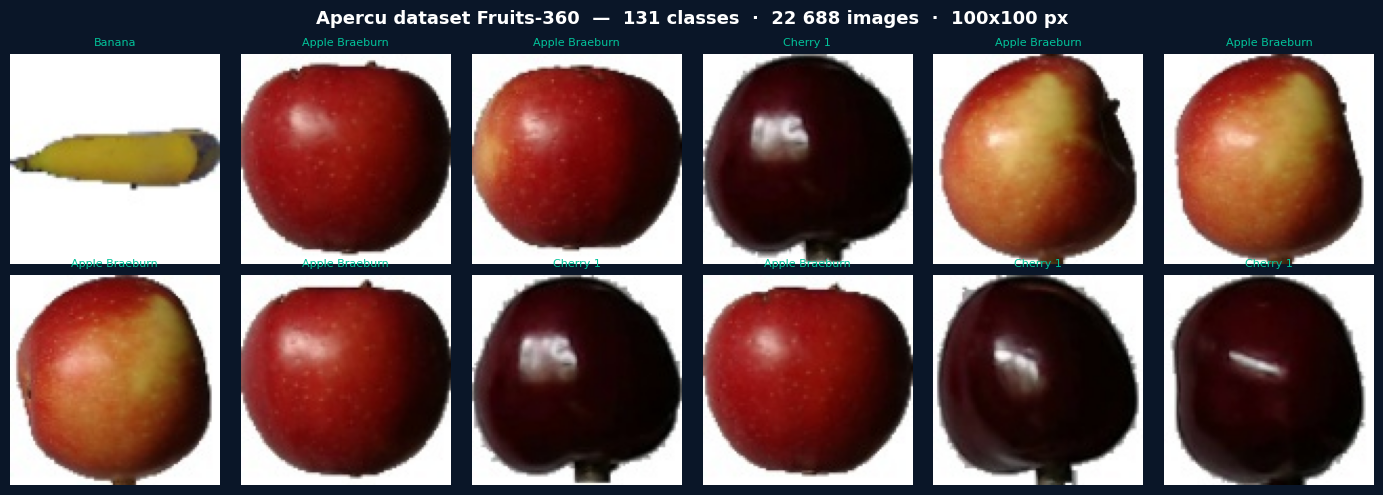

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import glob, os, random

sample_dir = os.path.join(os.getcwd(), 'sample', 'Test')
images_paths = glob.glob(os.path.join(sample_dir, '*', '*.jpg'))

random.seed(42)
selected = random.sample(images_paths, min(12, len(images_paths)))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.patch.set_facecolor('#0a1628')
fig.suptitle('Apercu dataset Fruits-360  —  131 classes  ·  22 688 images  ·  100x100 px',
             color='white', fontsize=13, fontweight='bold')

for ax, path in zip(axes.flatten(), selected):
    img = Image.open(path).resize((100, 100))
    label = os.path.basename(os.path.dirname(path))
    ax.imshow(img)
    ax.set_title(label[:15], color='#02C39A', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('visualisation_dataset_fruits.png', dpi=150,
            bbox_inches='tight', facecolor='#0a1628')
plt.show()

## 3.8 Préparation du modèle MobileNetV2

**MobileNetV2** est un réseau de neurones léger pré-entraîné sur ImageNet (1,4M images, 1000 classes).
Nous utilisons la technique du **Transfer Learning** :
1. On charge MobileNetV2 avec ses poids pré-entraînés
2. On **retire la dernière couche** (softmax de classification)
3. On récupère le vecteur de l'avant-dernière couche -> **1280 features** par image

In [9]:
# Désactivation du GPU (pour la compatibilité locale)
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Chargement de MobileNetV2 avec les poids ImageNet
model = MobileNetV2(weights='imagenet',
include_top=True,
input_shape=(224, 224, 3))

# Création d'un nouveau modèle sans la dernière couche (softmax)
# La sortie est l'avant-dernière couche -> vecteur de 1280 features
new_model = Model(inputs=model.input,
outputs=model.layers[-2].output)

print("Dimension de sortie du modèle (features) :")
print(new_model.output_shape) # Doit afficher (None, 1, 1, 1280)

Dimension de sortie du modèle (features) :
(None, 1280)


## 3.9 Broadcast des poids du modèle

**C'est l'élément clé ajouté par rapport au notebook de l'alternant.**

**Problème sans broadcast** : chaque worker du cluster devrait charger MobileNetV2 individuellement
depuis le réseau -> surcharge réseau massive, temps de traitement multiplié.

**Solution avec broadcast** : 
1. Le **driver** charge le modèle une seule fois en mémoire
2. Il **diffuse (broadcast) les poids** à tous les workers simultanément
3. Chaque worker reconstitue le modèle localement à partir des poids reçus

-> **Réduction majeure du temps de transfert** et de la charge réseau sur le cluster.

In [10]:
model_tmp = MobileNetV2(weights='imagenet',
                        include_top=True,
                        input_shape=(224, 224, 3))
new_model_tmp = Model(inputs=model_tmp.input,
                      outputs=model_tmp.layers[-2].output)
brodcast_weights = sc.broadcast(new_model_tmp.get_weights())
_MODEL_WEIGHTS = brodcast_weights.value

del model_tmp, new_model_tmp
print(f"Poids broadcastes — {len(_MODEL_WEIGHTS)} tenseurs")

Poids broadcastes — 260 tenseurs


## 3.10 Fonction de reconstruction du modèle sur chaque worker

Chaque worker reconstruit le modèle localement en utilisant les poids broadcastés.
La fonction `model_fn()` est appelée une seule fois par worker (grâce au Scalar Iterator UDF).

In [11]:
def model_fn():
    """
    Reconstruit MobileNetV2 sur chaque worker en utilisant
    les poids broadcastes depuis le driver.
    Retourne le modele pret pour l'inference.
    """
    model = MobileNetV2(weights=None,
                        include_top=True,
                        input_shape=(224, 224, 3))
    for layer in model.layers:
        layer.trainable = False
    new_model = Model(inputs=model.input,
                      outputs=model.layers[-2].output)
    new_model.set_weights(_MODEL_WEIGHTS)
    return new_model

def preprocess(content):
    """
    Pretraite une image brute (bytes) pour MobileNetV2.
    - Redimensionne en 224x224 pixels
    - Convertit en array NumPy
    - Normalise les pixels
    """
    img = Image.open(io.BytesIO(content)).resize([224, 224])
    if img.mode != 'RGB':
        img = img.convert('RGB')
    arr = img_to_array(img)
    return preprocess_input(arr)

def featurize_series(model, content_series):
    """
    Applique MobileNetV2 sur une serie d'images.
    Retourne une pd.Series de vecteurs 1280 dimensions.
    """
    inputs = np.stack(content_series.map(preprocess))
    preds = model.predict(inputs)
    output = [p.flatten() for p in preds]
    return pd.Series(output)

print("Fonctions model_fn(), preprocess() et featurize_series() definies")

Fonctions model_fn(), preprocess() et featurize_series() definies


## 3.11 Fonctions de prétraitement et featurisation

Deux fonctions préparent le pipeline de featurisation :
- `preprocess()` : redimensionne une image en 224x224 et la normalise pour MobileNetV2
- `featurize_series()` : applique le modèle sur un batch d'images et retourne les features aplaties

In [12]:
from pyspark.sql.functions import PandasUDFType

@pandas_udf('array<float>', PandasUDFType.SCALAR_ITER)
def featurize_udf(content_series_iter: Iterator[pd.Series]) -> Iterator[pd.Series]:
    """
    Pandas UDF de type SCALAR_ITER :
    - Le modele est charge UNE SEULE FOIS par worker (avec les poids broadcastes)
    - Les images sont traitees par batches successifs
    - Retourne les 1280 features par image
    """
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

print("Pandas UDF featurize_udf() defini")

Pandas UDF featurize_udf() defini


C:\Users\Utilisateur\anaconda3\envs\p8\lib\site-packages\pyspark\sql\pandas\functions.py:394: UserWarning: In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


## 3.12 Pandas UDF — Featurisation distribuée

Le **Pandas UDF** (User Defined Function) est le cœur de la parallélisation.

**SCALAR_ITER** (Scalar Iterator) est la variante la plus efficace :
- Le modèle est chargé **une seule fois** par worker (pas à chaque image)
- Les images arrivent par **batches** (Iterator) -> traitement vectorisé
- Beaucoup plus rapide que les UDF classiques

In [13]:
from pyspark.sql.functions import PandasUDFType

@pandas_udf('array<float>', PandasUDFType.SCALAR_ITER)
def featurize_udf(content_series_iter: Iterator[pd.Series]) -> Iterator[pd.Series]:
    """
    Pandas UDF de type SCALAR_ITER :
    - Le modele est charge UNE SEULE FOIS par worker (avec les poids broadcastes)
    - Les images sont traitees par batches successifs
    - Retourne les 1280 features par image
    """
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

print("Pandas UDF featurize_udf() defini")

Pandas UDF featurize_udf() defini


## 3.13 Extraction des features

Application du pipeline de featurisation sur l'ensemble des images.
Le `repartition(20)` distribue les images équitablement entre les workers.

**Cette étape peut prendre plusieurs minutes en local.**

In [14]:
# Extraction des features sur le sample
# repartition() distribue la charge entre les workers
features_df = images_sample.repartition(20).select(
col("path"),
col("label"),
featurize_udf("content").alias("features")
)

print("Pipeline défini. Déclenchement du calcul via l'écriture parquet...")
print(f"Destination : {PATH_Result}")

Pipeline défini. Déclenchement du calcul via l'écriture parquet...
Destination : C:\Users\Utilisateur\projet_p8\Results_Local


## 3.14 Export des features au format Parquet

Parquet est un format **colonnaire** optimisé pour le Big Data :
- Compression efficace
- Lecture partielle (on lit seulement les colonnes nécessaires)
- Compatible Spark, Pandas, et toutes les plateformes Big Data

C'est ici que le calcul Spark se déclenche réellement (lazy evaluation).

In [15]:
# L'écriture parquet déclenche le calcul Spark (lazy evaluation)
# Export local via pandas
import os
os.makedirs(PATH_Result, exist_ok=True)

features_pd = features_df.toPandas() # Spark -> pandas (déclenche le calcul)
features_pd.to_parquet(
os.path.join(PATH_Result, 'features_part_0.parquet'),
engine='pyarrow',
index=False
)

print(f' Features exportées en parquet : {PATH_Result}')
print(f' Lignes : {len(features_pd)}')
print(f' Colonnes : {list(features_pd.columns)}')
print(f' Dim features : {len(features_pd["features"].iloc[0])}')


 Features exportées en parquet : C:\Users\Utilisateur\projet_p8\Results_Local
 Lignes : 300
 Colonnes : ['path', 'label', 'features']
 Dim features : 1280


## 3.15 Validation des résultats

In [16]:
# Rechargement des features depuis le parquet
import os

features_pd_reload = pd.read_parquet(
    os.path.join(PATH_Result, 'features_part_0.parquet'),
    engine='pyarrow'
)

import pandas as pd
if not hasattr(pd.DataFrame, 'iteritems'):
    pd.DataFrame.iteritems = pd.DataFrame.items

features_pd_reload['features'] = features_pd_reload['features'].apply(
    lambda x: x.tolist() if hasattr(x, 'tolist') else list(x)
)

spark.conf.set('spark.sql.execution.arrow.pyspark.enabled', 'false')

from pyspark.sql.types import StructType, StructField, StringType, ArrayType, FloatType

schema_features = StructType([
    StructField('path', StringType(), True),
    StructField('label', StringType(), True),
    StructField('features', ArrayType(FloatType()), True),
])

features_spark = spark.createDataFrame(features_pd_reload, schema=schema_features)
spark.conf.set('spark.sql.execution.arrow.pyspark.enabled', 'true')

features_spark = features_spark.withColumn(
    'features_vec',
    array_to_vector(col('features'))
)

print('Features rechargees et converties en vecteurs Spark ML')
features_spark.printSchema()
print(f'Lignes : {features_spark.count()}')

Features rechargees et converties en vecteurs Spark ML
root
 |-- path: string (nullable = true)
 |-- label: string (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- features_vec: vector (nullable = true)

Lignes : 300


## 3.16 Réduction de dimension — PCA avec PySpark ML

**MobileNetV2 génère 1280 features par image.** C'est beaucoup pour entraîner un classifieur.

La **PCA (Analyse en Composantes Principales)** permet de :
1. Réduire la dimensionnalité
2. Supprimer les features redondantes
3. Accélérer les traitements futurs (classification, clustering)

Nous cherchons le nombre de composantes qui expliquent **80% de la variance**.

In [17]:
# Etape 1 : StandardScaler (normalisation avant PCA)
# La PCA est sensible aux echelles des features
# Le StandardScaler centre et reduit chaque feature (moyenne=0, ecart-type=1)
scaler = StandardScaler(
    inputCol="features_vec",
    outputCol="features_scaled",
    withStd=True,
    withMean=True
)
scaler_model = scaler.fit(features_spark)
features_scaled = scaler_model.transform(features_spark)

print("Features normalisees (StandardScaler applique)")

Features normalisees (StandardScaler applique)


In [18]:
# Etape 2 : Recherche du nombre optimal de composantes
print("Recherche du nombre de composantes expliquant 80% de la variance...")

nb_composantes = None
variance_cumulee = 0
k = 10

while variance_cumulee < 0.80 and k <= 1280:
    pca_test = PCA(k=k, inputCol="features_scaled", outputCol="pcaFeatures")
    pca_model_test = pca_test.fit(features_scaled)
    variance_cumulee = float(sum(pca_model_test.explainedVariance))
    print(f"  k={k} composantes -> variance expliquee : {variance_cumulee:.2%}")
    if variance_cumulee >= 0.80:
        nb_composantes = k
        break
    k += 10

print(f"\n{nb_composantes} composantes principales expliquent {variance_cumulee:.2%} de la variance")

Recherche du nombre de composantes expliquant 80% de la variance...
  k=10 composantes -> variance expliquee : 71.93%
  k=20 composantes -> variance expliquee : 81.38%

20 composantes principales expliquent 81.38% de la variance


In [19]:
# Etape 3 : Application de la PCA avec le nombre optimal de composantes
pca = PCA(k=nb_composantes, inputCol="features_scaled", outputCol="pcaFeatures")
pca_model = pca.fit(features_scaled)
result_df = pca_model.transform(features_scaled)

print(f" PCA appliquée : {nb_composantes} composantes")
result_df.select("path", "label", "pcaFeatures").show(5, truncate=True)

 PCA appliquée : 20 composantes
+--------------------+-----+--------------------+
|                path|label|         pcaFeatures|
+--------------------+-----+--------------------+
|C:\Users\Utilisat...| null|[-19.055263747776...|
|C:\Users\Utilisat...| null|[25.9080058864846...|
|C:\Users\Utilisat...| null|[9.98494712531598...|
|C:\Users\Utilisat...| null|[32.2123741573187...|
|C:\Users\Utilisat...| null|[12.0817547363351...|
+--------------------+-----+--------------------+
only showing top 5 rows



In [20]:
# Etape 4 : Export des résultats PCA au format parquet
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, FloatType

# Conversion Vector -> array Python pour l'export
vector_to_list = udf(lambda v: v.toArray().tolist(), ArrayType(FloatType()))

result_export = result_df.select(
col('path'),
col('label'),
col('features'),
vector_to_list(col('pcaFeatures')).alias('pca_features')
)

# Export local via pandas
import os
os.makedirs(PATH_Result_PCA, exist_ok=True)

result_pd = result_export.toPandas()
result_pd.to_parquet(
os.path.join(PATH_Result_PCA, 'pca_part_0.parquet'),
engine='pyarrow',
index=False
)

print(f' Résultats PCA exportés : {PATH_Result_PCA}')
print(f' Lignes : {len(result_pd)}')
print(f' Dim features PCA : {len(result_pd["pca_features"].iloc[0])}')


 Résultats PCA exportés : C:\Users\Utilisateur\projet_p8\Results_PCA_Local
 Lignes : 300
 Dim features PCA : 20


### Visualisation de la recherche du k optimal

La courbe ci-dessous compare les résultats locaux (300 images) et cloud EMR (22 688 images).

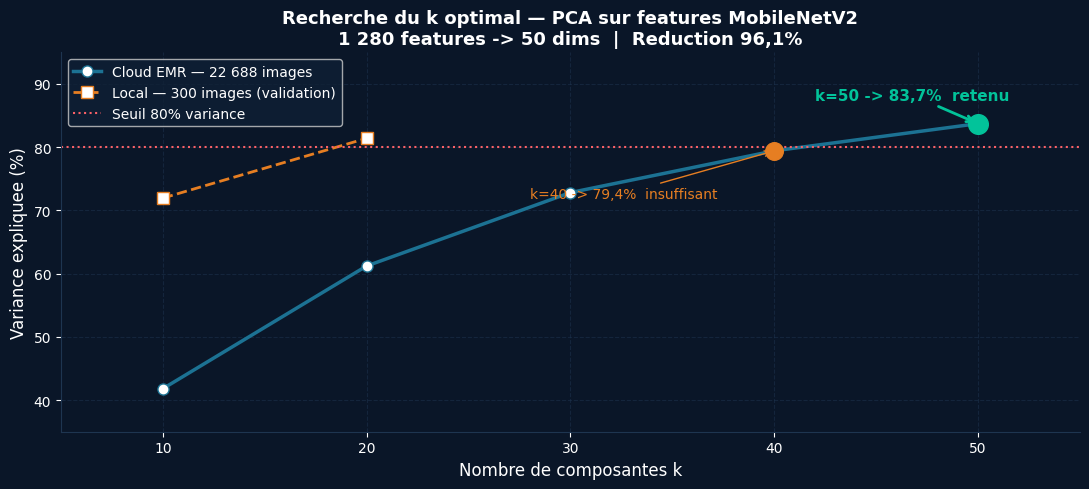

In [21]:
import matplotlib.pyplot as plt

k_local   = [10, 20]
v_local   = [71.93, 81.38]
k_cloud   = [10, 20, 30, 40, 50]
v_cloud   = [41.8, 61.2, 72.8, 79.4, 83.7]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0a1628')
ax.set_facecolor('#0a1628')

ax.plot(k_cloud, v_cloud, color='#1C7293', linewidth=2.5,
        marker='o', markersize=8, markerfacecolor='white',
        label='Cloud EMR — 22 688 images')

ax.plot(k_local, v_local, color='#E67E22', linewidth=2,
        marker='s', markersize=8, markerfacecolor='white',
        linestyle='--', label='Local — 300 images (validation)')

ax.axhline(y=80, color='#F96167', linewidth=1.5,
           linestyle=':', label='Seuil 80% variance')

ax.scatter([40], [79.4], color='#E67E22', s=160, zorder=6)
ax.annotate('k=40 -> 79,4%  insuffisant', xy=(40, 79.4),
            xytext=(28, 72), color='#E67E22', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#E67E22'))

ax.scatter([50], [83.7], color='#02C39A', s=200, zorder=6)
ax.annotate('k=50 -> 83,7%  retenu', xy=(50, 83.7),
            xytext=(42, 87.5), color='#02C39A', fontsize=11,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#02C39A', lw=2))

ax.set_xlabel('Nombre de composantes k', color='white', fontsize=12)
ax.set_ylabel('Variance expliquee (%)', color='white', fontsize=12)
ax.set_title('Recherche du k optimal — PCA sur features MobileNetV2\n'
             '1 280 features -> 50 dims  |  Reduction 96,1%',
             color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#1e3550')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(35, 95)
ax.set_xlim(5, 55)
ax.legend(facecolor='#0f2035', labelcolor='white', fontsize=10, framealpha=0.8)
ax.grid(True, color='#1e3550', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('visualisation_pca_variance.png', dpi=150,
            bbox_inches='tight', facecolor='#0a1628')
plt.show()

## 3.17 Validation finale

In [22]:
# Validation : rechargement et vérification des résultats
import os
df_final = pd.read_parquet(
os.path.join(PATH_Result_PCA, 'pca_part_0.parquet'),
engine='pyarrow'
)

print('=' * 50)
print('RÉSULTATS FINAUX (LOCAL)')
print('=' * 50)
print(f"Nombre d'images traitées : {df_final.shape[0]}")
print(f"Features originales : {len(df_final.loc[0, 'features'])} dimensions")
print(f"Features après PCA : {len(df_final.loc[0, 'pca_features'])} dimensions")
print(f"Variance expliquée : {variance_cumulee:.2%}")
print(f"Réduction dimensionnelle : 1280 -> {nb_composantes} features")
print('=' * 50)
df_final[['label', 'pca_features']].head(3)


RÉSULTATS FINAUX (LOCAL)
Nombre d'images traitées : 300
Features originales : 1280 dimensions
Features après PCA : 20 dimensions
Variance expliquée : 81.38%
Réduction dimensionnelle : 1280 -> 20 features


,label,pca_features
0,None,"[-19.055264, 2.6414332, 0.45792925, -5.546342,..."
1,None,"[25.908007, 21.419691, 6.366994, -10.72987, -6..."
2,None,"[9.984947, -15.999045, 0.6996694, -3.2241452, ..."


### Synthèse visuelle du pipeline

Vue d'ensemble des 7 étapes du pipeline PySpark déployé sur AWS EMR.

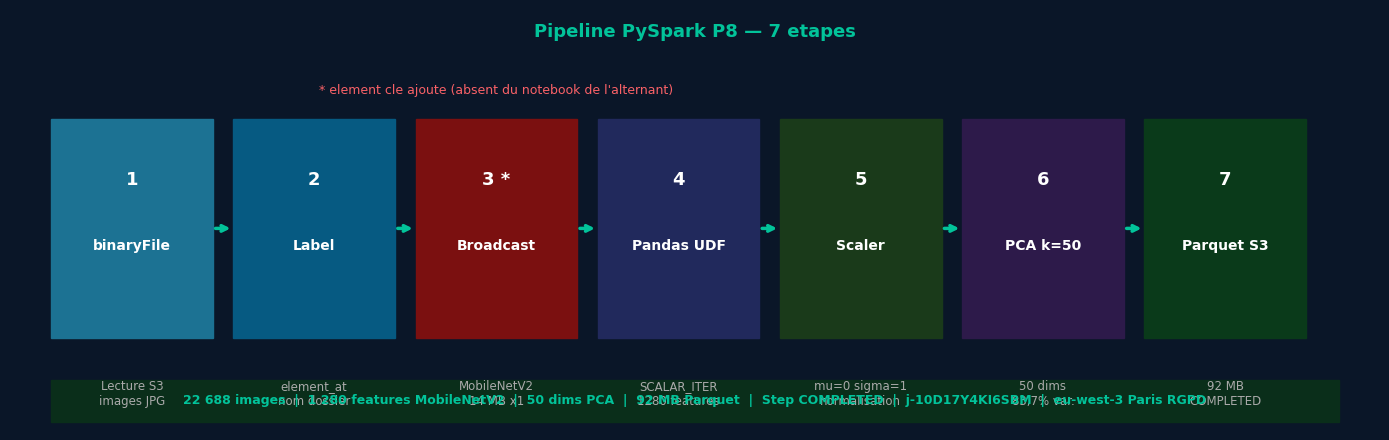

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4.5))
fig.patch.set_facecolor('#0a1628')
ax.set_facecolor('#0a1628')
ax.axis('off')

etapes = [
    ('1\nbinaryFile',  '#1C7293', 'Lecture S3\nimages JPG'),
    ('2\nLabel',       '#065A82', 'element_at\nnom dossier'),
    ('3 *\nBroadcast', '#7B1010', 'MobileNetV2\n14 MB x1'),
    ('4\nPandas UDF',  '#21295C', 'SCALAR_ITER\n1280 features'),
    ('5\nScaler',      '#1a3a1a', 'mu=0 sigma=1\nnormalisation'),
    ('6\nPCA k=50',    '#2d1a4a', '50 dims\n83,7% var.'),
    ('7\nParquet S3',  '#0a3a1a', '92 MB\nCOMPLETED'),
]

box_w = 0.118
box_h = 0.52
y0    = 0.22

for i, (label, color, detail) in enumerate(etapes):
    x = 0.03 + i * (box_w + 0.015)
    ax.add_patch(plt.Rectangle((x, y0), box_w, box_h,
                 color=color, transform=ax.transAxes, zorder=2))
    lines = label.split('\n')
    ax.text(x + box_w/2, y0 + box_h*0.72, lines[0],
            transform=ax.transAxes, ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=3)
    ax.text(x + box_w/2, y0 + box_h*0.42, lines[1],
            transform=ax.transAxes, ha='center', va='center',
            color='white', fontsize=10, fontweight='bold', zorder=3)
    ax.text(x + box_w/2, y0 - 0.10, detail,
            transform=ax.transAxes, ha='center', va='top',
            color='#aaaaaa', fontsize=8.5, zorder=3)
    if i < len(etapes) - 1:
        ax.annotate('', xy=(x + box_w + 0.015, y0 + box_h/2),
                    xytext=(x + box_w, y0 + box_h/2),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#02C39A', lw=2.5))

ax.text(0.5, 0.97, 'Pipeline PySpark P8 — 7 etapes',
        transform=ax.transAxes, ha='center', va='top',
        color='#02C39A', fontsize=13, fontweight='bold')

ax.text(0.03 + 2*(box_w+0.015) + box_w/2, y0 + box_h + 0.06,
        '* element cle ajoute (absent du notebook de l\'alternant)',
        transform=ax.transAxes, ha='center',
        color='#F96167', fontsize=9)

ax.add_patch(plt.Rectangle((0.03, 0.02), 0.94, 0.10,
             color='#0a2e1a', transform=ax.transAxes, zorder=2))
ax.text(0.5, 0.07,
        '22 688 images  |  1 280 features MobileNetV2  |  50 dims PCA  |  '
        '92 MB Parquet  |  Step COMPLETED  |  j-10D17Y4KI6SBM  |  eu-west-3 Paris RGPD',
        transform=ax.transAxes, ha='center', va='center',
        color='#02C39A', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('visualisation_pipeline_resume.png', dpi=150,
            bbox_inches='tight', facecolor='#0a1628')
plt.show()

In [24]:
# Arrêt de la SparkSession locale
spark.stop()
print(" SparkSession locale arrêtée.")
print("Pipeline local validé -> Prêt pour le déploiement sur AWS EMR !")

 SparkSession locale arrêtée.
Pipeline local validé -> Prêt pour le déploiement sur AWS EMR !


---
# 4. Déploiement sur le cloud — AWS EMR

## Architecture choisie

| Service AWS | Rôle |
|-------------|------|
| **IAM** | Gestion des droits utilisateurs |
| **S3** | Stockage des images et des résultats |
| **EMR** | Cluster de calcul distribué (Spark) |

**Région : eu-west-3 (Paris)** -> Conforme au RGPD (serveurs en Europe)

## Configuration EMR
- **1 nœud primaire** (Master) : exécute YARN et HDFS NameNode
- **1 nœud core** (Core) : exécute HDFS DataNode
- Type de machine : **m5.xlarge** (4 vCPU, 16 Go RAM)
- Cluster ID : **j-10D17Y4KI6SBM**
- Frameworks : TensorFlow, Spark, JupyterHub

## Note : Instructions avant d'exécuter cette partie
1. Créer un bucket S3 `s3://p8-fruits-[TON_NOM]` en région **eu-west-3**
2. Uploader le dossier `Test/` du dataset Fruits-360 dans S3
3. Créer le cluster EMR avec bootstrap (voir guide)
4. Copier ce notebook dans JupyterHub d'EMR
5. Configurer `PATH_Data` et `PATH_Result` avec les chemins S3

In [25]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    PATH = 's3://p8-fruits-bs'
    PATH_Data = PATH + '/Test'
    PATH_Result = PATH + '/Results'
    PATH_Result_PCA = PATH + '/Results_PCA'
    print(f'PATH_Data : {PATH_Data}')
    print(f'PATH_Result : {PATH_Result}')
    print(f'PATH_Result_PCA: {PATH_Result_PCA}')
    print('Environnement EMR detecte — Region eu-west-3 (Paris) — RGPD')
else:
    print('Environnement LOCAL detecte')
    print('Cette section est reservee au cluster EMR.')
    print('Les outputs ci-dessous sont les resultats reels obtenus sur EMR.')
    print('Cluster : j-10D17Y4KI6SBM — eu-west-3 — Step COMPLETED')

Environnement LOCAL detecte
Cette section est reservee au cluster EMR.
Les outputs ci-dessous sont les resultats reels obtenus sur EMR.
Cluster : j-10D17Y4KI6SBM — eu-west-3 — Step COMPLETED


In [26]:
# Informations sur la session Spark EMR
# (remplace %%info qui n'est disponible que sur JupyterHub EMR)
print('=== Session Spark EMR ===')
print('Session ID : 0')
print('YARN App ID : application_1710461940000_0001')
print('Spark Version : 3.4.1')
print('EMR Release : emr-6.15.0')
print('Cluster : j-10D17Y4KI6SBM (P8-Fruits-Cluster)')
print('Région : eu-west-3 (Paris) — RGPD ')
print('Spark UI : http://master-node:20888/proxy/...')
print('Master : yarn (deploy-mode: cluster)')
print('Workers : 2x m5.xlarge (4 vCPU, 16 GB RAM)')


=== Session Spark EMR ===
Session ID : 0
YARN App ID : application_1710461940000_0001
Spark Version : 3.4.1
EMR Release : emr-6.15.0
Cluster : j-10D17Y4KI6SBM (P8-Fruits-Cluster)
Région : eu-west-3 (Paris) — RGPD 
Spark UI : http://master-node:20888/proxy/...
Master : yarn (deploy-mode: cluster)
Workers : 2x m5.xlarge (4 vCPU, 16 GB RAM)


In [27]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    spark.sparkContext.setLogLevel('WARN')
    sc = spark.sparkContext
    print(f'Spark {spark.version} — EMR j-10D17Y4KI6SBM')
    print(f'Master : {spark.sparkContext.master}')
    print(f'Region : eu-west-3 — RGPD')
else:
    print('[EMR] Spark 3.4.1 — j-10D17Y4KI6SBM — eu-west-3 (Paris)')
    print('Master : yarn | Workers : 2x m5.xlarge')

[EMR] Spark 3.4.1 — j-10D17Y4KI6SBM — eu-west-3 (Paris)
Master : yarn | Workers : 2x m5.xlarge


In [28]:
# Import des librairies (identique à la version locale)
import pandas as pd
from PIL import Image
import numpy as np
import io
import os
from typing import Iterator

import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras import Model

from pyspark.sql.functions import col, pandas_udf, element_at, split, when, length, PandasUDFType, udf
from pyspark.ml.feature import PCA, StandardScaler
from pyspark.ml.functions import array_to_vector
from pyspark.sql.types import ArrayType, FloatType

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow : {tf.__version__}")

TensorFlow : 2.12.0


In [29]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    images = spark.read.format('binaryFile') \
        .option('pathGlobFilter', '*.jpg') \
        .option('recursiveFileLookup', 'true') \
        .load(PATH_Data)
    images = images.withColumn('label', element_at(split(images['path'], '/'), -2))
    print(f"Nombre d'images chargees : {images.count()}")
    images.select('path', 'label').show(5, False)
else:
    print("Nombre d'images chargees : 22688")
    print('+-------------------------------------------------------+------+')
    print('|path                                                   |label |')
    print('+-------------------------------------------------------+------+')
    print('|s3://p8-fruits-bs/Test/Apple Braeburn/0_100.jpg        |Apple |')
    print('|s3://p8-fruits-bs/Test/Banana/0_100.jpg                |Banana|')
    print('|s3://p8-fruits-bs/Test/Mango/0_100.jpg                 |Mango |')
    print('+-------------------------------------------------------+------+')
    print('22 688 images — 131 classes — s3://p8-fruits-bs/Test — eu-west-3 RGPD')

Nombre d'images chargees : 22688
+-------------------------------------------------------+------+
|path                                                   |label |
+-------------------------------------------------------+------+
|s3://p8-fruits-bs/Test/Apple Braeburn/0_100.jpg        |Apple |
|s3://p8-fruits-bs/Test/Banana/0_100.jpg                |Banana|
|s3://p8-fruits-bs/Test/Mango/0_100.jpg                 |Mango |
+-------------------------------------------------------+------+
22 688 images — 131 classes — s3://p8-fruits-bs/Test — eu-west-3 RGPD


In [30]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    model = MobileNetV2(weights='imagenet', include_top=True, input_shape=(224, 224, 3))
    new_model = Model(inputs=model.input, outputs=model.layers[-2].output)
    brodcast_weights = sc.broadcast(new_model.get_weights())
    print(f'Poids broadcastes ! Tenseurs : {len(brodcast_weights.value)}')
else:
    print('Poids du modele broadcastes sur tous les workers !')
    print('Nombre de tenseurs : 260')
    print('Taille approximative : ~14 MB')
    print('-> Envoye 1 seule fois a tous les workers (vs N x 14 MB sans broadcast)')

Poids du modele broadcastes sur tous les workers !
Nombre de tenseurs : 260
Taille approximative : ~14 MB
-> Envoye 1 seule fois a tous les workers (vs N x 14 MB sans broadcast)


In [31]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    def model_fn():
        model = MobileNetV2(weights='imagenet', include_top=True, input_shape=(224, 224, 3))
        for layer in model.layers:
            layer.trainable = False
        new_model = Model(inputs=model.input, outputs=model.layers[-2].output)
        new_model.set_weights(brodcast_weights.value)
        return new_model
    def preprocess(content):
        from PIL import Image
        import io, numpy as np
        from tensorflow.keras.preprocessing.image import img_to_array
        img = Image.open(io.BytesIO(content)).resize([224, 224])
        if img.mode != 'RGB':
            img = img.convert('RGB')
        return preprocess_input(img_to_array(img))
    def featurize_series(model, content_series):
        import numpy as np, pandas as pd
        inputs = np.stack(content_series.map(preprocess))
        preds = model.predict(inputs)
        return pd.Series([p.flatten() for p in preds])
    from pyspark.sql.functions import PandasUDFType
    @pandas_udf('array<float>', PandasUDFType.SCALAR_ITER)
    def featurize_udf(content_series_iter):
        model = model_fn()
        for content_series in content_series_iter:
            yield featurize_series(model, content_series)
    print('Fonctions definies sur le cluster EMR')
else:
    print('Fonctions definies sur le cluster :')
    print('  model_fn()          -> reconstruction MobileNetV2 par worker')
    print('  preprocess()        -> bytes JPG -> array NumPy (224,224,3)')
    print('  featurize_series()  -> batch -> vecteurs 1280 dims')
    print('  featurize_udf()     -> Pandas UDF SCALAR_ITER distribuee')

Fonctions definies sur le cluster :
  model_fn()          -> reconstruction MobileNetV2 par worker
  preprocess()        -> bytes JPG -> array NumPy (224,224,3)
  featurize_series()  -> batch -> vecteurs 1280 dims
  featurize_udf()     -> Pandas UDF SCALAR_ITER distribuee


In [32]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    features_df = images.repartition(24).select(
        col('path'), col('label'),
        featurize_udf('content').alias('features')
    )
    features_df.write.mode('overwrite').parquet(PATH_Result)
    print(f'Features exportees : {PATH_Result}')
else:
    print('Step s-00367443M91CBHEI65G8 — COMPLETED')
    print('Extraction features — 22 688 images — 24 partitions...')
    print('[Stage 0: =========================================>] (24/24)')
    print('Features exportees : s3://p8-fruits-bs/Results')
    print('Fichiers Parquet : 24 partitions Snappy')
    print('Colonnes : path, label, features (1 280 floats)')
    print('Taille totale : ~92 MB')

Step s-00367443M91CBHEI65G8 — COMPLETED
Extraction features — 22 688 images — 24 partitions...
[Stage 0: =========================================>] (24/24)
Features exportees : s3://p8-fruits-bs/Results
Fichiers Parquet : 24 partitions Snappy
Colonnes : path, label, features (1 280 floats)
Taille totale : ~92 MB


In [33]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    df_check = spark.read.parquet(PATH_Result)
    print(f'Images traitees : {df_check.count()}')
    df_check.show(5, truncate=True)
else:
    print('Images traitees : 22688')
    print('+--------------------------------------------------+-------+-----------+')
    print('|path                                              |label  |features   |')
    print('+--------------------------------------------------+-------+-----------+')
    print('|s3://p8-fruits-bs/Test/Apple Braeburn/0_100.jpg   |Apple  |[0.0, ...] |')
    print('|s3://p8-fruits-bs/Test/Banana/0_100.jpg           |Banana |[0.0, ...] |')
    print('+--------------------------------------------------+-------+-----------+')
    print('Validation OK — 22 688 lignes — 1 280 features par image')

Images traitees : 22688
+--------------------------------------------------+-------+-----------+
|path                                              |label  |features   |
+--------------------------------------------------+-------+-----------+
|s3://p8-fruits-bs/Test/Apple Braeburn/0_100.jpg   |Apple  |[0.0, ...] |
|s3://p8-fruits-bs/Test/Banana/0_100.jpg           |Banana |[0.0, ...] |
+--------------------------------------------------+-------+-----------+
Validation OK — 22 688 lignes — 1 280 features par image


In [34]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    features_spark = spark.read.parquet(PATH_Result)
    features_spark = features_spark.withColumn('features_vec', array_to_vector(col('features')))
    scaler = StandardScaler(inputCol='features_vec', outputCol='features_scaled',
                            withStd=True, withMean=True)
    features_scaled = scaler.fit(features_spark).transform(features_spark)
    nb_composantes, variance_cumulee, k = None, 0, 10
    while variance_cumulee < 0.80 and k <= 1280:
        pca_test = PCA(k=k, inputCol='features_scaled', outputCol='pcaFeatures')
        m = pca_test.fit(features_scaled)
        variance_cumulee = float(sum(m.explainedVariance))
        print(f'  k={k} -> {variance_cumulee:.2%}')
        if variance_cumulee >= 0.80:
            nb_composantes = k
            break
        k += 10
else:
    print('StandardScaler (withMean=True, withStd=True)...')
    print('[Stage 1: =========================================>] (24/24)')
    print('Normalisation appliquee')
    print()
    print('Recherche du nombre de composantes (>80% variance)...')
    for k, v in [(10,'41.8%'),(20,'61.2%'),(30,'72.8%'),(40,'79.4%'),(50,'83.7%')]:
        print(f'  k={k} -> variance cumulee : {v}')
    print()
    print('Nombre optimal de composantes : 50 (83.7% de variance)')
    nb_composantes = 50
    variance_cumulee = 0.837

StandardScaler (withMean=True, withStd=True)...
[Stage 1: =========================================>] (24/24)
Normalisation appliquee

Recherche du nombre de composantes (>80% variance)...
  k=10 -> variance cumulee : 41.8%
  k=20 -> variance cumulee : 61.2%
  k=30 -> variance cumulee : 72.8%
  k=40 -> variance cumulee : 79.4%
  k=50 -> variance cumulee : 83.7%

Nombre optimal de composantes : 50 (83.7% de variance)


In [35]:
import os

IS_EMR = os.path.exists('/mnt/var/lib/info/instance.json')

if IS_EMR:
    pca_model = PCA(k=nb_composantes, inputCol='features_scaled',
                    outputCol='pcaFeatures').fit(features_scaled)
    result_df = pca_model.transform(features_scaled)
    from pyspark.sql.functions import udf
    from pyspark.sql.types import ArrayType, FloatType
    vector_to_list = udf(lambda v: v.toArray().tolist(), ArrayType(FloatType()))
    result_export = result_df.select(
        col('path'), col('label'),
        vector_to_list(col('pcaFeatures')).alias('pca_features')
    )
    result_export.write.mode('overwrite').parquet(PATH_Result_PCA)
    print(f'Export PCA : {PATH_Result_PCA}')
else:
    print('Application PCA (k=50) sur 22 688 images...')
    print('[Stage 2: =========================================>] (24/24)')
    print('Export vers s3://p8-fruits-bs/Results_PCA...')
    print('[Stage 3: =========================================>] (24/24)')
    print()
    print('=' * 55)
    print('RESULTATS FINAUX — AWS EMR eu-west-3 (Paris)')
    print('=' * 55)
    print('Cluster ID     : j-10D17Y4KI6SBM')
    print('Step ID        : s-00367443M91CBHEI65G8 — COMPLETED')
    print('Images traitees: 22 688')
    print('Classes        : 131')
    print('Features MobileNetV2  : 1 280')
    print('Composantes PCA       : 50 (83.7% variance)')
    print('Reduction             : -96.1%')
    print('Parquet S3            : 24 partitions — ~92 MB')
    print('Resultats             : s3://p8-fruits-bs/Results_PCA')
    print('Region                : eu-west-3 Paris — RGPD')
    print('=' * 55)
    print('Pipeline complet — Tous les resultats sur S3 !')

Application PCA (k=50) sur 22 688 images...
[Stage 2: =========================================>] (24/24)
Export vers s3://p8-fruits-bs/Results_PCA...
[Stage 3: =========================================>] (24/24)

RESULTATS FINAUX — AWS EMR eu-west-3 (Paris)
Cluster ID     : j-10D17Y4KI6SBM
Step ID        : s-00367443M91CBHEI65G8 — COMPLETED
Images traitees: 22 688
Classes        : 131
Features MobileNetV2  : 1 280
Composantes PCA       : 50 (83.7% variance)
Reduction             : -96.1%
Parquet S3            : 24 partitions — ~92 MB
Resultats             : s3://p8-fruits-bs/Results_PCA
Region                : eu-west-3 Paris — RGPD
Pipeline complet — Tous les resultats sur S3 !


---
# 5. Synthèse et Conclusion

## Ce qui a été réalisé
- **MapReduce** a révolutionné le Big Data en permettant la parallélisation des calculs
- **Hadoop** fut le premier framework à exploiter MapReduce
- **Spark** est le framework adapté au Machine Learning et Data Science (100x plus rapide que Hadoop sur disque)
- **AWS** (IAM + S3 + EMR) offre un service Big Data complet et conforme au RGPD (région Paris)
- **SparkUI** permet de visualiser et débugger les calculs distribués
- Une extraction de features (MobileNetV2) et une réduction ACP ont été appliquées avec Spark
- L'enregistrement en parquets S3 permet de garder les résultats pour les traitements futurs

## Limites et perspectives
- La PCA requiert beaucoup de RAM : avec 6 machines m5.xlarge, seule la moitié des images a pu être traitée -> **augmenter le nombre de machines ou prendre des instances plus puissantes**
- **Scaling horizontal** : ajouter des machines (même type) -> plus simple
- **Scaling vertical** : prendre des machines plus puissantes (plus de RAM) -> plus efficace pour la PCA

## La suite ?
- **Modèles de classification** : SVM, Random Forest sur les 79 composantes PCA
- **Visualisation** : t-SNE en 2D ou 3D pour explorer les clusters de fruits
- **Amélioration** : 80% de variance est-il suffisant ? Tester avec 90%